# Cell Embeddings with BrainBeacon

This tutorial shows how to obtain **cell embeddings** from a pretrained **BrainBeacon** checkpoint
(Heffel2024 MERFISH as an example).

Users can run BrainBeacon on their own AnnData by replacing:
- `adata_path`
- `species` / `assay` (if needed)
- `gene_mean_path` (assay/platform-specific prior stats)


In [1]:
import os
import torch

from brainbeacon.pipeline.cell_embedding import run_bbcellformer_pipeline
from brainbeacon.configs.config import resolve_path
from brainbeacon.configs.config_train import config_train


/raid/zhangchengming/miniconda3/envs/brainbeacon_dgx1/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/raid/zhangchengming/miniconda3/envs/brainbeacon_dgx1/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/raid/zhangchengming/miniconda3/envs/brainbeacon_dgx1/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/raid/zhangchengming/miniconda3/envs/brainbeacon_dgx1/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_mtx from `anndata` is deprecated. Import anndata.io.read_mtx instead.
  warnings.warn(msg, FutureWarning)
/raid/zhangchengming/miniconda

## Device setup


In [2]:
# NOTE: If you want to pin a specific GPU, uncomment and edit the line below.
# os.environ["CUDA_VISIBLE_DEVICES"] = "0"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"Using GPU: {torch.cuda.get_device_name(torch.cuda.current_device())}")


Using device: cuda
Using GPU: Tesla V100-SXM2-16GB


## Paths and dataset config
**Example dataset (Heffel2024 MERFISH, GEO: GSE213950)**

- GEO page: https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE213950
- File: `GSE213950_HPC_spatial_MERFISH_01132024.h5ad.gz`

If you don't have the `.h5ad` locally yet, you can download the file from GEO
and place it under the path you want (e.g. `BrainBeacon/data/.../processed/`),
then update `adata_path` accordingly.

In [9]:
BASE_DIR = "/raid/zhangchengming/BrainBeacon-master"

dataset_name = "heffel2024"
species = "human"
assay = "merfish"

input_data_dir = os.path.join(
    BASE_DIR, "data", "MERFISH_Human_Heffel2024Temporally3D", "processed"
)
adata_path = os.path.join(input_data_dir, "Heffel2024Temporally3D.h5ad")

gene_dict_path = resolve_path("GENE_DICT_PATH")
prior_dir = resolve_path("PRIOR_DIR")
gene_mean_path = os.path.join(prior_dir, "merfish_gene_nonzero_means.npy")

print("adata_path:", adata_path)
print("gene_dict_path:", gene_dict_path)
print("gene_mean_path:", gene_mean_path)

assert os.path.exists(adata_path), f"adata_path not found: {adata_path}"
assert os.path.exists(gene_dict_path), f"gene_dict_path not found: {gene_dict_path}"
assert os.path.exists(gene_mean_path), f"gene_mean_path not found: {gene_mean_path}"


adata_path: /raid/zhangchengming/BrainBeacon-master/data/MERFISH_Human_Heffel2024Temporally3D/processed/Heffel2024Temporally3D.h5ad
gene_dict_path: /raid/zhangchengming/BrainBeacon-master/prior_knowledge/model_h5ad_1211.h5ad
gene_mean_path: /raid/zhangchengming/BrainBeacon-master/prior_knowledge/merfish_gene_nonzero_means.npy


## Pretrained checkpoints


In [4]:
pretrain_dir = resolve_path("PRETRAIN_DIR")

bb_ckpt_name = "epoch_0_step_800000_0.33B.pt"
bb_ckpt_path = os.path.join(pretrain_dir, bb_ckpt_name)

cellplm_ckpt_path = os.path.join(
    BASE_DIR,
    "downstream_tasks", "train_cellformer", "epoch_0_step_800000_0.33B",
    "cellformer_epoch100.pt"
)

print("bb_ckpt_path:", bb_ckpt_path)
print("cellplm_ckpt_path:", cellplm_ckpt_path)

assert os.path.exists(bb_ckpt_path), f"bb_ckpt_path not found: {bb_ckpt_path}"
assert os.path.exists(cellplm_ckpt_path), f"cellplm_ckpt_path not found: {cellplm_ckpt_path}"


bb_ckpt_path: /raid/zhangchengming/BrainBeacon-master/pretrained/epoch_0_step_800000_0.33B.pt
cellplm_ckpt_path: /raid/zhangchengming/BrainBeacon-master/downstream_tasks/train_cellformer/epoch_0_step_800000_0.33B/cellformer_epoch100.pt


## Output naming


In [5]:
method_name = "brainbeacon"
output_prefix = f"{dataset_name}_{method_name}"
output_dir = os.path.join(
    BASE_DIR, "downstream_tasks", "cell_clustering", "outputs", dataset_name, method_name
)
os.makedirs(output_dir, exist_ok=True)

print("output_dir:", output_dir)
print("output_prefix:", output_prefix)


output_dir: /raid/zhangchengming/BrainBeacon-master/downstream_tasks/cell_clustering/outputs/heffel2024/brainbeacon
output_prefix: heffel2024_brainbeacon


## Run pipeline


In [6]:
n_hvg = 1000
cd_weight = 0.02

do_fit = False
fit_epochs = 10

adata = run_bbcellformer_pipeline(
    adata_path=adata_path,
    specie=species,  # pipeline uses "specie" as argument name
    assay=assay,
    gene_dict_path=gene_dict_path,
    gene_mean_path=gene_mean_path,
    bb_ckpt_path=bb_ckpt_path,
    cellplm_ckpt_path=cellplm_ckpt_path,
    output_dir=output_dir,
    output_prefix=output_prefix,
    config_train=config_train,
    n_hvg=n_hvg,
    cd_weight=cd_weight,
    use_hvg=True,
    use_batch=True,
    use_spatial=True,
    weight_mode="expression",
    force_tokenize=False,
    do_fit=do_fit,
    fit_epochs=fit_epochs,
    device=device,
)

print("Pipeline finished.")
print("obsm keys:", list(adata.obsm.keys()))
print("obs columns (first 30):", list(adata.obs.columns)[:30])


Tokenized data found (6 .parquet, 6 dirs). Skipping tokenization.
Skipping BB inference. Found existing file: /raid/zhangchengming/BrainBeacon-master/downstream_tasks/cell_clustering/outputs/heffel2024/brainbeacon/heffel2024_brainbeacon_bb_embeddings.npz
[INFO] Using explicitly provided CellFormer checkpoint: /raid/zhangchengming/BrainBeacon-master/downstream_tasks/train_cellformer/epoch_0_step_800000_0.33B/cellformer_epoch100.pt
********** gene list size: 92076 **********
********** loading skip parameters: set() **********
After filtering, 298 genes remain.


/raid/zhangchengming/BrainBeacon-master/brainbeacon/bbcellformer/utils/data.py:20: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  return torch.sparse_csr_tensor(x.indptr, x.indices, x.data, (x.shape[0], x.shape[1])).to_sparse().float().coalesce()


Model saved to /raid/zhangchengming/BrainBeacon-master/downstream_tasks/cell_clustering/outputs/heffel2024/brainbeacon/heffel2024_brainbeacon_cellformer.pt
Embeddings saved to /raid/zhangchengming/BrainBeacon-master/downstream_tasks/cell_clustering/outputs/heffel2024/brainbeacon/heffel2024_brainbeacon_embeddings.npz
Pipeline finished.
obsm keys: ['H3K9me3', 'K27Ac', 'LamA', 'Nup98', 'Pol2PSer2', 'Sc35', 'X_diffmap', 'X_fov', 'X_h_score', 'X_norm', 'X_pca', 'X_raw', 'X_spatial', 'X_umap', 'blank', 'spatial', 'bb_emb', 'X_emb', 'X_pred']
obs columns (first 30): ['volm', 'x_um_abs', 'y_um_abs', 'zc', 'xc', 'yc', 'leiden', 'region', 'L1', 'dpt_pseudotime', 'final_anno_v3', 'hpc_regional', 'fimbria_regional', 'hpcRG', 'fimbriaRG', 'ventricular_regional', 'ventricularRG', 'refined_volume', 'cell_label', 'slice', 'species', 'split', 'platform', 'valid_split', 'batch', 'x_FOV_px', 'y_FOV_px']


## UMAP (colored by Leiden)


/raid/zhangchengming/miniconda3/envs/brainbeacon_dgx1/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


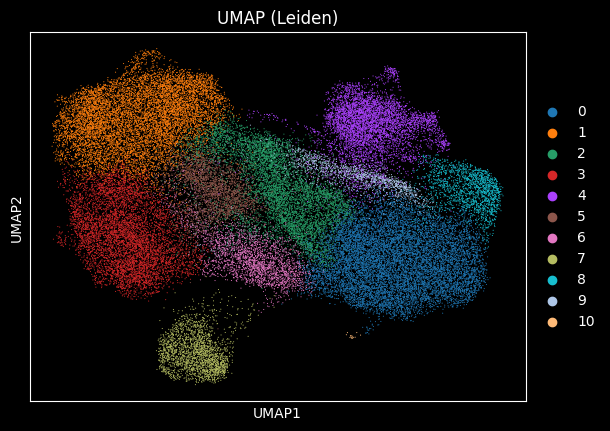

In [7]:
import scanpy as sc

# Use X_emb for downstream UMAP (as requested)
assert "X_emb" in adata.obsm, "Expected `adata.obsm['X_emb']` for UMAP, but it was not found."

# Compute UMAP if not already present
if "X_umap" not in adata.obsm:
    sc.pp.neighbors(adata, use_rep="X_emb")
    sc.tl.umap(adata)

# Compute Leiden if not already present
if "leiden" not in adata.obs:
    sc.tl.leiden(adata, resolution=1.0)

sc.pl.umap(
    adata,
    color="leiden",
    legend_loc="right margin",
    title="UMAP (Leiden)",
    show=True,
)


## Spatial plot (optional)

If your AnnData contains spatial coordinates in `adata.obsm['spatial']` (Scanpy convention),
you can visualize clusters in tissue space:


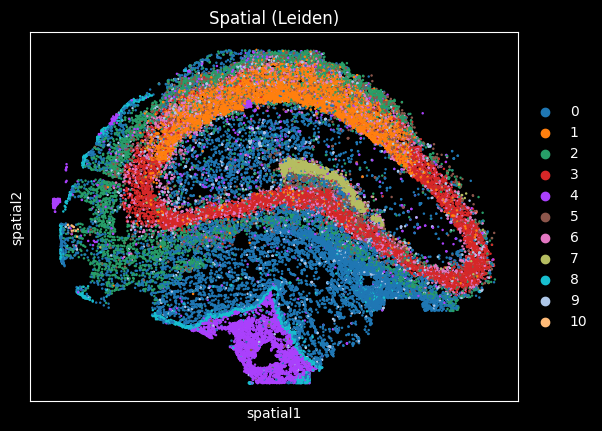

In [8]:
# Spatial plot (optional)
import numpy as np
import scanpy as sc

if "spatial" in adata.obsm:
    spatial = adata.obsm["spatial"]

    # Convert DataFrame -> numpy, or keep numpy as-is
    if hasattr(spatial, "to_numpy"):
        spatial = spatial.to_numpy()

    # Ensure (n_cells, 2)
    spatial = np.asarray(spatial)
    if spatial.ndim != 2 or spatial.shape[1] < 2:
        raise ValueError(f"adata.obsm['spatial'] must be (n_cells, >=2), got {spatial.shape}")

    # Keep only first 2 dims
    adata.obsm["spatial"] = spatial[:, :2]

    sc.pl.spatial(
        adata,
        color="leiden",
        legend_loc="right margin",
        spot_size=40,
        title="Spatial (Leiden)",
        show=True,
    )
else:
    print("Skip spatial plot: `adata.obsm['spatial']` not found.")

## Notes for users

- Cell embeddings are stored in `adata.obsm['X_emb']`.
- This notebook uses **`X_emb`** to compute UMAP and colors by **`leiden`**.
- To run on another dataset, replace:
  - `adata_path`
  - `species` / `assay` (if needed)
  - `gene_mean_path` (platform-specific prior stats)
